# **TITANIC DATA ANALYSIS PROJECT**

**1. Import Required Libraries**

   Imported libraries required for data manipulation and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

Loaded the Titanic dataset and displayed the first few records.

In [ ]:
df=pd.read_csv('tested.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**3. Dataset Overview**



*   Shape shows rows and columns.
*   Info provides data types and missing values.


*   Describe provides statistical summary.





In [ ]:
df.shape

(418, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


**4. Data Quality Assessment**

Identified duplicate records and missing values before preprocessing.

**Duplicate Check**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Missing Value Check**

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


**5. Data Cleaning**

**Handling Missing Values**



*   Median used for age and fare because it is resistant to outliers.
*   Cabin filled with "unknown" because majority values were missing.



In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_1859/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
df['Fare'].fillna(df['Fare'].median(), inplace=True)

/tmp/ipykernel_1859/309285478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(), inplace=True)


In [ ]:
df['Cabin']=df['Cabin'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**6. Encoding Categorical Data**

Converted categorical values into numerical form for analysis.

In [ ]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

**7. Outlier Detection**



*   Detected extreme values using the Interquartile Range (IQR) method.

*   Features such as Sex, Pclass, cabin and embarked are categorical variables that represent categories rather than measurable quantities. Since categorical data does not have extreme numerical values, outlier detection methods like IQR and capping are not applicable. Therefore capping was applied only to numerical features such as fare were genuine outliers were present.





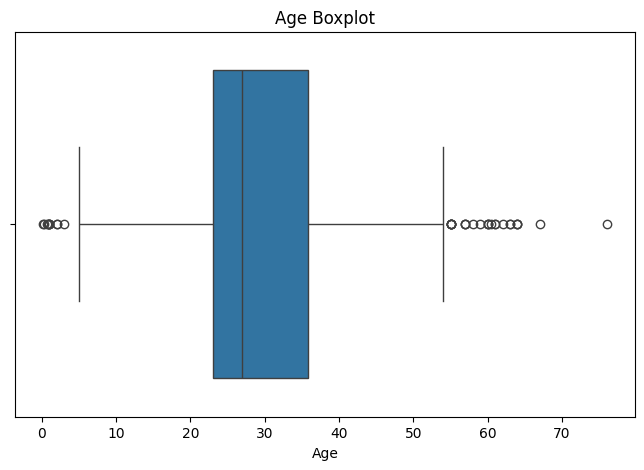

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

>The box plot summarises the spread of passenger ages and highlights potential outliers This is to detect unusual age values and understand age variability A few passengers had unusually high ages compared to the majority of passengers resulting in visible outliers.

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound =", lower)
print("Upper Bound =", upper)

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]

print("Number of outliers =", len(outliers))

Lower Bound = 3.875
Upper Bound = 54.875
Number of outliers = 36


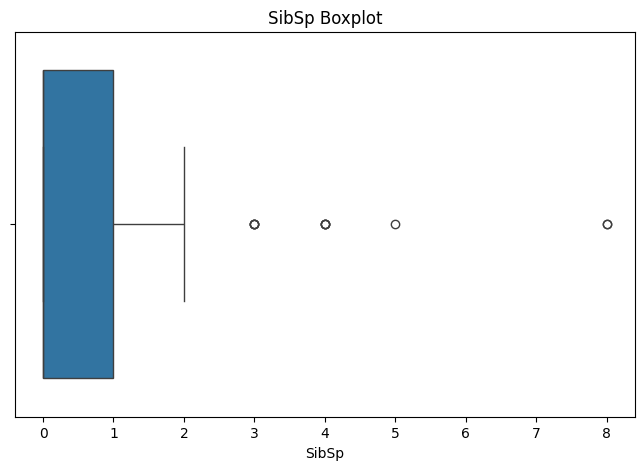

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SibSp'])
plt.title("SibSp Boxplot")
plt.show()

>This boxplot shows the distribution of the number of siblings or spouses travelling with each passenger This is to identify unusual family size observations Most passengers travelled with few or no siblings or spouses while a small number Travelled with larger family groups.

In [ ]:
Q1 = df['SibSp'].quantile(0.25)
Q3 = df['SibSp'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound =", lower)
print("Upper Bound =", upper)

outliers = df[(df['SibSp'] < lower) | (df['SibSp'] > upper)]

print("Number of outliers =", len(outliers))

Lower Bound = -1.5
Upper Bound = 2.5
Number of outliers = 11


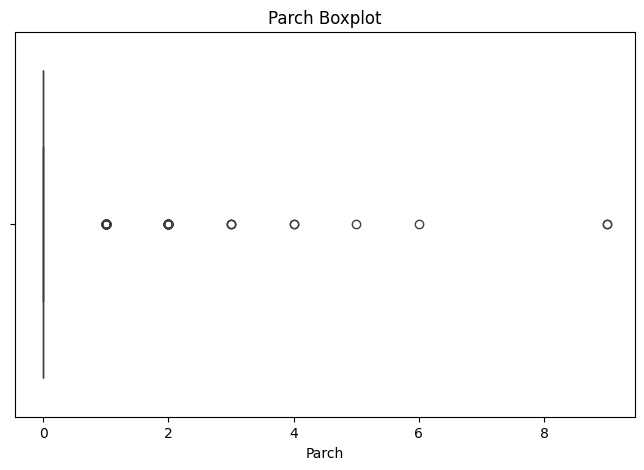

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Parch'])
plt.title("Parch Boxplot")
plt.show()

>This visualisation displays the distribution of parents or children travelling with Each passenger To understand family composition and deduct extreme values Most passengers travelled without parents or children while only a few travelled with larger family groups.

In [ ]:
Q1 = df['Parch'].quantile(0.25)
Q3 = df['Parch'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound =", lower)
print("Upper Bound =", upper)

outliers = df[(df['Parch'] < lower) | (df['Parch'] > upper)]

print("Number of outliers =", len(outliers))

Lower Bound = 0.0
Upper Bound = 0.0
Number of outliers = 94


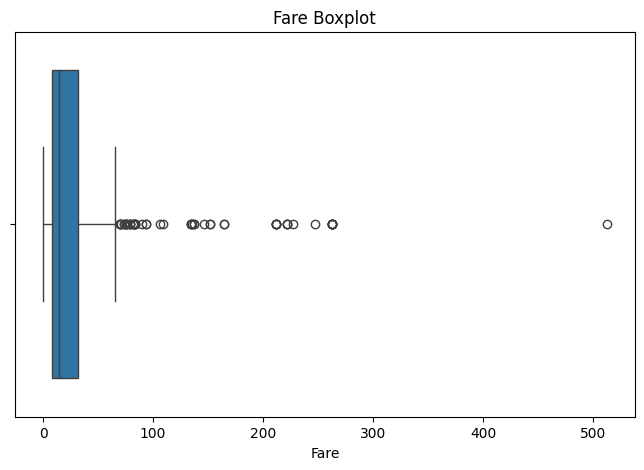

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

>This box plot shows the spread of tickets fares and identifies extreme fare values. To detect Fare outlier Before applying outlier treatment Several passengers paid exceptionally high fares creating significantl outliers in the fare feature.

In [ ]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound =", lower)
print("Upper Bound =", upper)

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("Number of outliers =", len(outliers))

Lower Bound = -27.468312499999996
Upper Bound = 66.8359875
Number of outliers = 55


**8. Outlier Treatment**

Applied capping to reduce the impact of extreme fare values Which occur only in numerical variables.

In [ ]:
df['Fare'] = df['Fare'].clip(lower=lower, upper=upper)

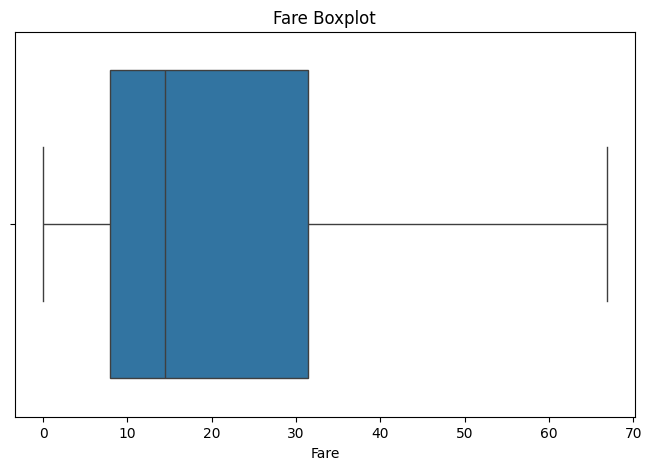

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

**9. Exploratory Data Analysis**

Examined the distribution of key categical variables.

**Survival Distribution**

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,266
1,152


**Passenger class distribution**

In [ ]:
df['Pclass'].value_counts()

,count
Pclass,
3,218
1,107
2,93


**Sex Distribution**

In [ ]:
df['Sex'].value_counts()

,count
Sex,
0,266
1,152


**Cabin distribution**

In [ ]:
df['Cabin'].value_counts()

,count
Cabin,
Unknown,327
B57 B59 B63 B66,3
B45,2
C23 C25 C27,2
C78,2
...,...
B41,1
C7,1
D40,1


**Embarked distribution**

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


**10. Visualization**

**UNIVARIATE ANALYSIS - HISTOGRAM**

**1. Age Distribution**

This histogram displays how passengers are distributed across different age groups.

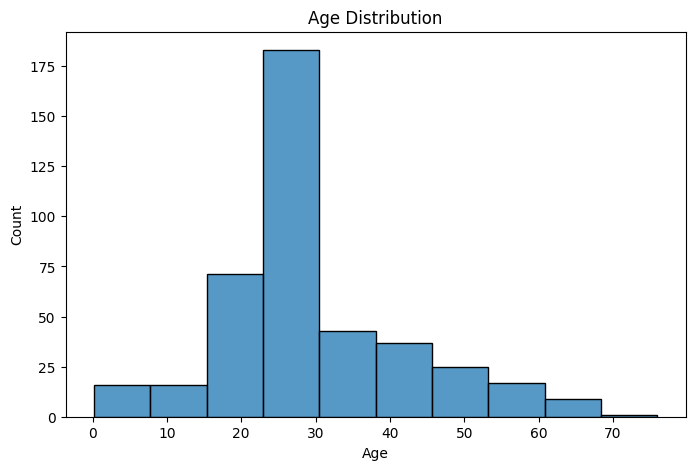

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'].dropna(), bins=10)
plt.title("Age Distribution")
plt.show()


**2. Fare Distribution**



This histogram shows The distribution of ticket fares Paid by passengers.

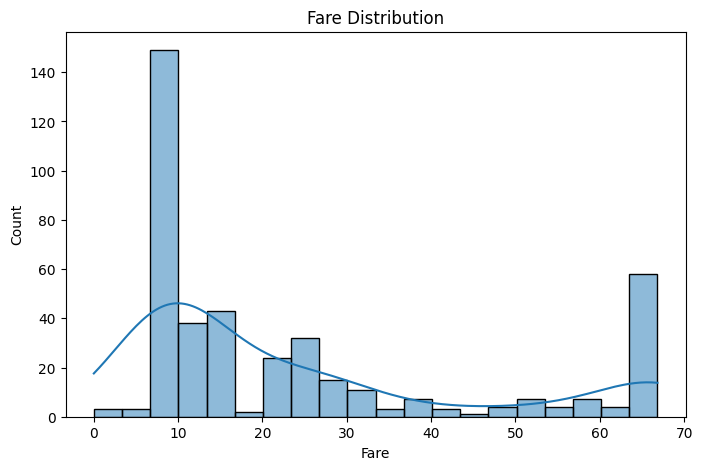

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'],bins=20,kde=True)
plt.title("Fare Distribution")
plt.show()

**BIVARIATE ANALYSIS - COUNTPLOT**

**1. Gender vs Survival**

This count Plot shows the number of passengers who survived and those who did not survive the Titanic disaster.

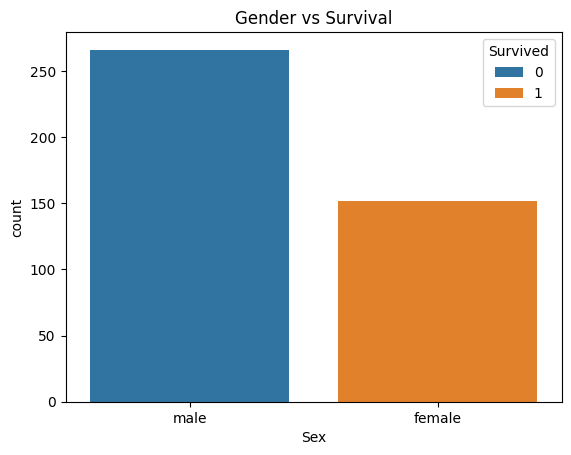

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

**2. Passenger class vs Survival**

This visualisation displays the Number of passengers Survived in First class Second class and third class.

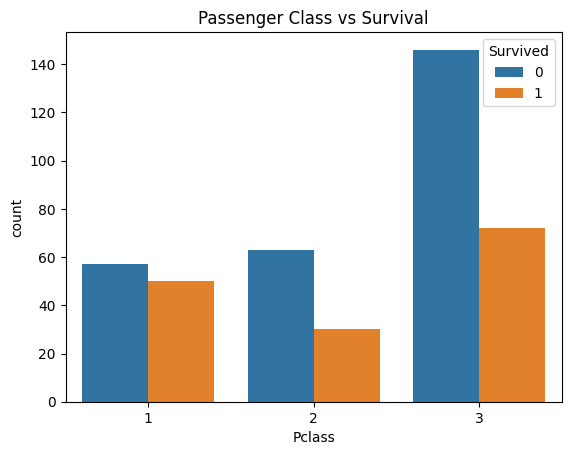

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

**3. Survived by Embarked Port**

This visualization compares survival outcomes for passengers from different embarkation ports to explore whether embarkation location had any relationship with survival. survival patterns varied across embarkation ports with southampton Contributing the largest number of passengers and survivors due to its higher passenger count.

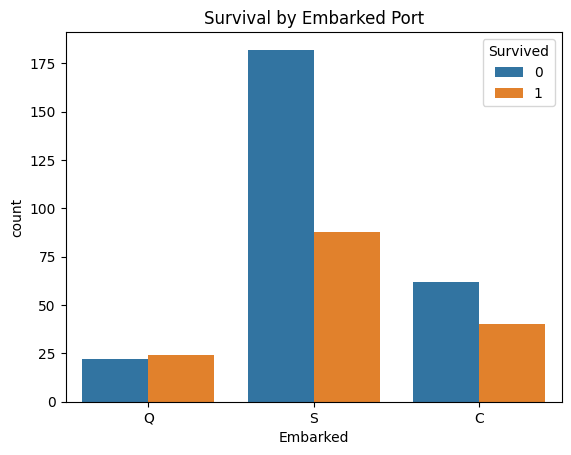

In [ ]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarked Port')
plt.show()

**MULTIVARIATE ANALYSIS**

**1. Correlation Heatmap**

This heat map visualises The correlation between numerical variables in the data set To identify relationships between features and survival. Passenger class, gender and fare show notable relationships with survival, indicating that these features may be important predictors of passenger survival.

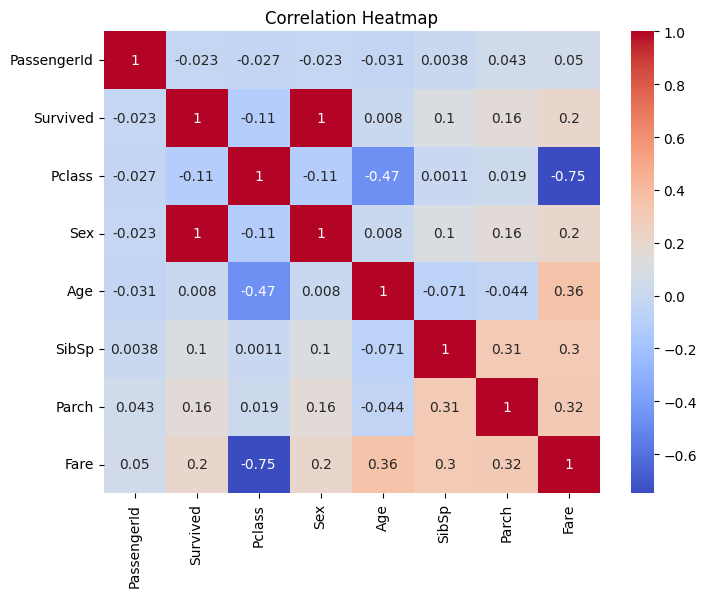

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

**11. Insights**



*   Male passenger had a higher survival rate than female passengers.
*   Passengers travelling in first class showed better survival chances compared to second and third class passengers.


*   Most passengers were between 20 and 40 years old.
*   Ticket fares were highly right-skewed indicating that only a small number of passengers paid very high fares.


*   Most passengers embarked from Southampton (S).
*   Fare and passenger class show a noticeable relationship with survival.


*   The dataset contains significant missing values in the cabin column which were handled by replacing them with "unknown".










**12. Conclusion**

   The Titanic dataset was successfully cleaned, preprocessed and analyzed using python. Missing values were handled appropriately outliers were identified using the IQR method an important visualization were generated to understand passenger characteristics. The analysis revealed that survival was strongly influenced by gender and passenger class. Female Passengers and first class travellers had significantly higher survival rates. Most passengers belonged to the third class and embarked from Southampton. Ticket Fare showed a skewed distribution, while age was concentrated mainly between 20 and 40 years. Overall, the project demonstrates the complete workflow of Exploratory Data Analysis (EDA), including data cleaning, preprocessing, vizualisation and insight generation, providing meaningful understanding of the Titanic data set.